
- 1 -> loading gtfs, laoding network (done)
- 2 -> defining pathways (done)
- 3 -> merging routes (done)
- 4 -> near stops (done)
- 5 -> routing
- 6 -> filtering
- 7 -> labeling

# Load network and gtfs

In [2]:
import osmnx as ox
import pandas as pd

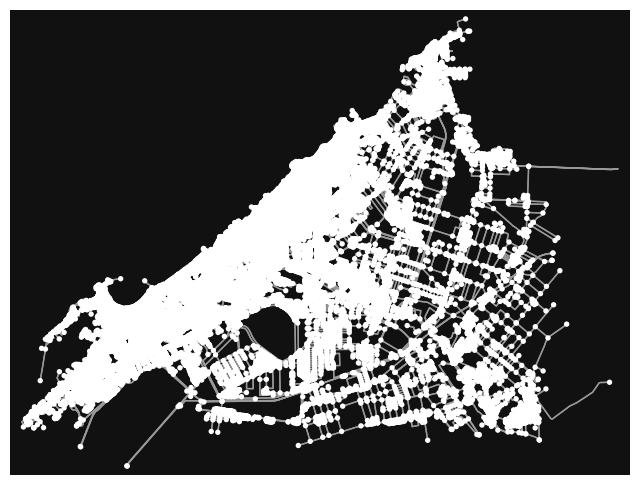

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [35]:
g = ox.graph_from_xml("labeled.osm", bidirectional=True, simplify=True)

ox.plot_graph(g)


In [36]:
# import gtfs files
path = "C:\\Users\\ahmed\\Downloads\\gtfsAlex"
stops = pd.read_csv(path + "/stops.txt")
routes = pd.read_csv(path + "/routes.txt")
trips = pd.read_csv(path + "/trips.txt")
stop_times = pd.read_csv(path + "/stop_times.txt")
shapes = pd.read_csv(path + "/shapes.txt")

# construct pathways

In [34]:
pathways = pd.read_csv('trip_pathways.csv')

# merge trips to the network

In [37]:
import osmnx as ox
import pandas as pd

# Assume 'g', 'stops', and 'stop_times' DataFrames are already loaded

# 1. Build a mapping from each stop_id to the set of trip_ids that use it.
# This is more efficient than iterating row by row.
stop_to_trips = (
    stop_times.groupby('stop_id')['trip_id']
    .apply(set)
    .to_dict()
)

# 2. Find the nearest graph node for every stop in a single, vectorized operation.
# This is much faster than finding them one by one in a loop.
stop_nodes = ox.distance.nearest_nodes(
    g,
    X=stops['stop_lon'].values,
    Y=stops['stop_lat'].values
)
# Create a mapping from stop_id to its nearest node_id
stop_to_node_map = pd.Series(stop_nodes, index=stops['stop_id']).to_dict()

# 3. Attach the list of trip_ids to each unique node.
# We iterate through each stop and its mapped node.
for stop_id, node_id in stop_to_node_map.items():
    # Get all trips for the current stop
    trips_at_stop = stop_to_trips.get(stop_id)
    
    if trips_at_stop:
        # Check if the 'trips' attribute already exists on the node.
        # If not, create it as an empty set.
        if 'trips' not in g.nodes[node_id]:
            g.nodes[node_id]['trips'] = set()
            
        # Add the new trips to the set for that node.
        # Using a set automatically handles duplicates.
        g.nodes[node_id]['trips'].update(trips_at_stop)

# 4. (Optional) Convert the sets of trips to lists.
# This is useful if you need to save the graph to a format like JSON or GraphML.
for node, data in g.nodes(data=True):
    if 'trips' in data:
        data['trips'] = list(data['trips'])

print("Finished mapping trips to graph nodes.")

Finished mapping trips to graph nodes.


In [38]:
# Create a dictionary of nodes that have trip data attached
nodes_with_trips = {n: data for n, data in g.nodes(data=True) if 'trips' in data}

# Print a count of how many nodes have trip information
print(len(nodes_with_trips), "nodes have trips attached")

# Print the trips for the first 10 nodes as a sample
print("\\n--- Sample of nodes and their associated trips ---")
for node, data in list(nodes_with_trips.items())[:10]:
    print(f"Node {node}: {data['trips']}")


284 nodes have trips attached
\n--- Sample of nodes and their associated trips ---
Node 81312379: ['zZjzzNbMESUGofW2jqGDZ-07:00:00', '3JTmhQmnxSU9cPkJSaSlE-07:00:00', 'Hn0eoDFbdIiLk49QaqFeX-07:00:00', 'GVMY3J8hLKwB3k_XzZZNA-07:00:00', '3CgzuUO_dn1teCfMyugyc-07:00:00', 'pCUExpIx94RHG6BGAhT6a-07:00:00', 'iGgUl6NwJYqGWhVkUHdiu-07:00:00']
Node 260754134: ['LYcY_J8e-Dijvjm6uZhgZ-07:00:00', 'bd7828viXdflnfuupm3s6-07:00:00', 'tObSXctDA10XZJ6oW1EYp-07:00:00', '3DsaT0dcW0e0BLcyD3Q6E-07:00:00', 'EoBxLx54RiTmwf0L64PXs-07:00:00', 'J3ADe7YQWUaBHH8Z_00Ou-07:00:00', 'E3cKTAI5hrMdq3gv0l-3g-07:00:00', 'R1qyf44TfvStHmjMCiKfC-07:00:00', 'RmCIDxJQKwF7GOCKKX3Oh-07:00:00']
Node 260758565: ['divI9MoAnOSksgYUNogFE-07:00:00']
Node 260758678: ['MrihzTWrnXBOK-ItJhoR8-07:00:00', 'U5q_TMc5BJ7jtZPVBLLIC-07:00:00', 'KmoDyTTsPPrzF7JK4J700-07:00:00', 'JjBliHamEx0YUxbao3vZS-07:00:00', 'H4Zrbg3RLebdgA2rD0SL4-07:00:00', 'LrAbpnGcNy8Ljz0FMNTPN-07:00:00', 'qGoxkcgxJLIYDgVV9cYQ6-07:00:00', '4dazyxD50LYtjM4jq9_Ot-07:00:00', 

Node 261726784 data:
  y: 31.2066219
  x: 29.9059031
  trips: ['bAHUtWeGgy-NzZiHpbdim-07:00:00', 'Cl-oT7WLLDtvd9UF3t3WF-07:00:00', 'pvjC2m5XDlTvQWgPayp9C-07:00:00', 'dWfTv7gA4CztWg-ijXkTe-07:00:00', 'bd7828viXdflnfuupm3s6-07:00:00', 'OI7bd_u7laDmk8SxgppK0-07:00:00', 'znJ4UDxPXmPvAbkcg1zot-07:00:00', 'wyt-c9kVSmo-uyx4zLFYT-07:00:00', 'tObSXctDA10XZJ6oW1EYp-07:00:00', 'EoBxLx54RiTmwf0L64PXs-07:00:00', '_xaRNY3_AfOnhpf5yTE3A-07:00:00', 't3fihouAmNU32d_e7msfe-07:00:00', 'gqntW1mb4ahLW_IHlR39R-07:00:00', 'OVbnm1WLeW59vl_wEqm66-07:00:00', 'keUygmfQjUMNwNeSanmRs-07:00:00', '40rOFL2qzN26P2ty7q_b9-07:00:00', 'RbB2w0p-_BgwRa6AbSa-b-07:00:00', 'd84WDadbu5AjbQpkTV2r4-07:00:00', 'PyvMsU4izplRo5xNtmlK3-07:00:00', '3DsaT0dcW0e0BLcyD3Q6E-07:00:00', 'E3cKTAI5hrMdq3gv0l-3g-07:00:00', 'RmCIDxJQKwF7GOCKKX3Oh-07:00:00', 'udcnz_0kW2tOMy6xB2_Ng-07:00:00', '9ByH2YQ54cshi1Sj8kgPQ-07:00:00', 'LYcY_J8e-Dijvjm6uZhgZ-07:00:00', 'eVKw5V4GKYTFMFEU2cbKc-07:00:00', 'nnllgPNq1yuc-OXURFNAG-07:00:00', 'Tv3p8704smtFY_z3ZH

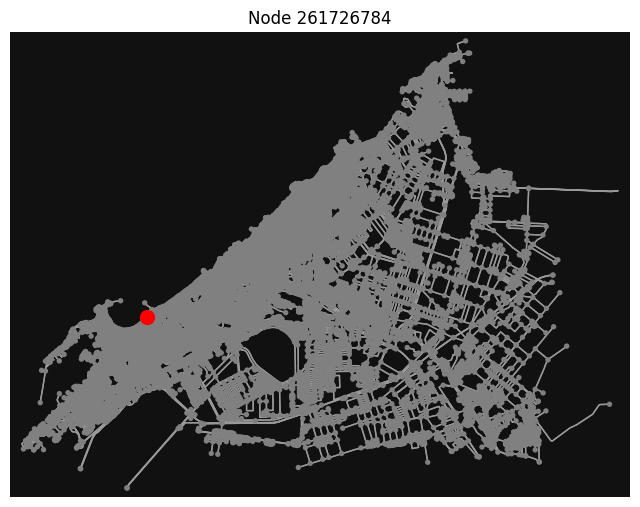

In [39]:

node_id = 261726784

if node_id in g.nodes:
    data = g.nodes[node_id]
    print(f"Node {node_id} data:")
    for key, value in data.items():
        print(f"  {key}: {value}")
    
    # Optionally display location of node on map
    import matplotlib.pyplot as plt
    fig, ax = ox.plot_graph(g, node_color="grey", show=False, close=False)
    x = g.nodes[node_id]['x']
    y = g.nodes[node_id]['y']
    ax.scatter(x, y, color="red", s=100, zorder=10)
    ax.set_title(f"Node {node_id}")
    plt.show()
else:
    print(f"Node {node_id} not found in graph.")


# Find reachable routes from start and end points

In [40]:
import heapq

def explore_trips(G, source, cutoff=float("inf")):
    """
    Finds the shortest path from a source node to the nearest node for every trip
    reachable within the cutoff distance, using a Dijkstra-like expansion.
    """
    # Dijkstra-like initialization
    dist = {source: 0.0}
    prev = {}
    pq = [(0.0, source)]
    visited = set()

    # Results dictionary: trip_id -> (distance_m, end_node, path)
    trips = {}

    def reconstruct_path(node):
        # Helper to build the path from the 'prev' dictionary
        path = []
        while node in prev:
            path.append(node)
            node = prev[node]
        path.append(source)
        return list(reversed(path))

    while pq:
        d, node = heapq.heappop(pq)
        
        if d > cutoff:
            break
        if node in visited:
            continue
        visited.add(node)

        # Get the trip IDs attached to this node (changed from "routes")
        trip_vals = G.nodes[node].get("trips")
        if trip_vals:
            # Ensure trip_vals is iterable
            if not isinstance(trip_vals, (list, set, tuple)):
                trip_vals = [trip_vals]
            
            for trip_id in trip_vals:
                if trip_id is None:
                    continue
                
                # Check if we've found a shorter path to this trip
                best = trips.get(trip_id)
                if best is None or d < best[0]:
                    trips[trip_id] = (d, node, reconstruct_path(node))

        # Relax neighbors
        for nbr, edge_data in G[node].items():
            for _, attr in edge_data.items():
                length = attr.get("length", 1.0)
                new_dist = d + float(length)
                
                if new_dist <= cutoff and new_dist < dist.get(nbr, float("inf")):
                    dist[nbr] = new_dist
                    prev[nbr] = node
                    heapq.heappush(pq, (new_dist, nbr))

    return trips

In [41]:
import folium
import osmnx as ox

def display_trips_on_map(G, trips, start_node=None, zoom=16):
    """
    Display the discovered trip paths on an interactive Folium map.

    Parameters
    ----------
    G : networkx.MultiDiGraph
        The OSMnx graph.
    trips : dict
        Output from explore_trips(): {trip_id: (dist, node, path)}.
    start_node : int, optional
        The source node to mark on the map.
    zoom : int, optional
        Initial zoom level.
    """
    if not trips:
        print("No trips to display.")
        return None

    # Center map on start node or first trip's node
    if start_node is not None and start_node in G.nodes:
        center_lat = G.nodes[start_node]['y']
        center_lon = G.nodes[start_node]['x']
    else:
        # Fallback to the first available node if start_node is invalid
        first_node = next(iter(trips.values()))[1]
        center_lat = G.nodes[first_node]['y']
        center_lon = G.nodes[first_node]['x']

    m = folium.Map(location=[center_lat, center_lon], zoom_start=zoom, tiles="cartodbpositron")

    # Optional: add start node marker
    if start_node is not None and start_node in G.nodes:
        folium.Marker(
            location=(G.nodes[start_node]['y'], G.nodes[start_node]['x']),
            popup="Start Node",
            icon=folium.Icon(color="green", icon="play")
        ).add_to(m)

    # Use a color generator to make paths visually distinct
    colors = ox.plot.get_colors(len(trips))

    # Draw each trip path
    for i, (trip_id, (dist, node, path)) in enumerate(trips.items()):
        # Convert the node path to (lat, lon) coordinates
        coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in path]
        
        # Draw the walking path as a polyline
        folium.PolyLine(
            coords,
            color=colors[i],
            weight=4,
            opacity=0.8,
            tooltip=f"Trip: {trip_id}<br>Distance: {dist:.1f} m"
        ).add_to(m)

        # Mark the endpoint where the trip was reached
        folium.Marker(
            location=coords[-1],
            popup=f"Trip: {trip_id}<br>Distance: {dist:.1f} m",
            icon=folium.Icon(color="blue", icon="flag")
        ).add_to(m)

    return m

In [73]:
# --- 1. Define the starting point and find the nearest node ---
lon, lat = 29.96139328537071, 31.22968895248673
source_node = ox.distance.nearest_nodes(g, X=lon, Y=lat)

trip_to_route = trips.set_index('trip_id')['route_id'].to_dict()
route_id_to_name = routes.set_index('route_id')['route_long_name'].to_dict()

print(f"Starting trip exploration from node {source_node}...")

# --- 2. Find all reachable trips within a 1000m walking distance ---
# We use the updated 'explore_trips' function
start_trips = explore_trips(g, source_node, cutoff=1000)

# --- 3. Print the results ---
print("\n--- Results ---")
if start_trips:
    print(f"Found {len(start_trips)} reachable trips within 1km:")
    
    # Assumes 'trip_to_route' and 'route_id_to_name' dicts exist from your notebook
    for trip_id, (dist, node, path) in start_trips.items():
        route_id = trip_to_route.get(trip_id)
        route_name = route_id_to_name.get(route_id, "Unknown Route")
        
        print(f"\n- Trip '{trip_id}'")
        print(f"  Route: '{route_name}'")
        print(f"  Found at node {node} ({dist:.1f} meters away)")
        print(f"  Walking path (nodes): {path}")
else:
    print("No reachable trips found within 1km.")

# --- 4. Display all discovered paths on a single map ---
# We use the updated 'display_trips_on_map' function
if start_trips:
    trip_map = display_trips_on_map(g, start_trips, start_node=source_node)
    # In a Jupyter environment, this will display the map below the cell
    display(trip_map)

Starting trip exploration from node 4166047227...

--- Results ---
Found 5 reachable trips within 1km:

- Trip 'tL1NRyqKwJOCmUECmIQqO-07:00:00'
  Route: 'El-Sa'ah (Clock Square) - Sidi Gabir'
  Found at node 3969615351 (497.7 meters away)
  Walking path (nodes): [4166047227, 1886562849, 6977064734, 6977079033, 6977079054, 6987704483, 7006574878, 6977079053, 339078213, 339078215, 3969615351]

- Trip 'FUo5FExiKwUTpyTUJYA7R-07:00:00'
  Route: 'Asafra - Train Station (El-Shohada Square)'
  Found at node 7257436116 (653.2 meters away)
  Walking path (nodes): [4166047227, 1886562849, 6977064720, 6977064719, 4166054337, 1886562895, 6986740396, 6977079022, 4166048754, 1886562842, 6346410642, 339078211, 4709690776, 5064688375, 7257436116]

- Trip 'z8pSD1wGRKg4oVh4eC0Iw-07:00:00'
  Route: 'El-Sa'ah (Clock Square) - Sidi Gabir'
  Found at node 7257436116 (653.2 meters away)
  Walking path (nodes): [4166047227, 1886562849, 6977064720, 6977064719, 4166054337, 1886562895, 6986740396, 6977079022, 416

In [74]:
# --- 1. Define the starting point and find the nearest node ---
lon, lat = 29.94194179397711, 31.20775934404925
source_node = ox.distance.nearest_nodes(g, X=lon, Y=lat)
print(f"Starting trip exploration from node {source_node}...")

# --- 2. Find all reachable trips within a 1000m walking distance ---
# Using the correct 'explore_trips' function
target_trips = explore_trips(g, source_node, cutoff=1600)

# --- 3. Print the results ---
print("\n--- Results ---")
if target_trips:
    print(f"Found {len(target_trips)} reachable trips within 1km:")
    for trip_id, (dist, node, path) in target_trips.items():
        # Look up the route name using our mapping dictionaries
        route_id = trip_to_route.get(trip_id)
        route_name = route_id_to_name.get(route_id, "Unknown Route")
        print(f"- Route '{route_name}' (Trip: {trip_id}) found at node {node} ({dist:.1f} m away)")
else:
    print("No reachable trips found within 1km.")

# --- 4. Display all discovered paths on a single map ---
# Using the correct 'display_trips_on_map' function
if target_trips:
    trip_map = display_trips_on_map(g, target_trips, start_node=source_node)
    display(trip_map) 

Starting trip exploration from node 8432185075...

--- Results ---
Found 30 reachable trips within 1km:
- Route 'Ezbet Saad - Sidi Gabir' (Trip: TWnfYDX6BkJirORXmg2hv-07:00:00) found at node 6942587478 (145.6 m away)
- Route 'El-Mansheya - Ezbet Saad' (Trip: gqntW1mb4ahLW_IHlR39R-07:00:00) found at node 265746703 (199.9 m away)
- Route 'El-Mansheya - Ezbet Saad' (Trip: EglZxh1NkJA5Jax303ARy-07:00:00) found at node 6942587547 (226.8 m away)
- Route 'El-Mansheya - Green Plaza Mall' (Trip: rz-CFcB9J3xy60VYWjZAn-07:00:00) found at node 6942587547 (226.8 m away)
- Route 'Abo Soliman - El-Mansheya' (Trip: PAh8O-96IhPU2mfK1XGjm-07:00:00) found at node 6944660397 (640.4 m away)
- Route 'El-Mansheya - Smouha' (Trip: gp93eQ2WYNnUOJrA17bFP-07:00:00) found at node 6944660397 (640.4 m away)
- Route 'El-Mansheya - Hagar Al-Nawateyah (Namos Bridge)' (Trip: _npHlyCCY7o0R20RyqvT8-07:00:00) found at node 6944660397 (640.4 m away)
- Route 'Kilo 21 - Sidi Gabir' (Trip: ZBtB-FXg8HG9MZ8swYNuQ-07:00:00) foun

# Routing

In [75]:
from collections import defaultdict
trip_graph = defaultdict(list)
for _, row in pathways.iterrows():
    trip_graph[row['start_trip_id']].append(row['end_trip_id'])

print(f"Graph built with {len(trip_graph)} unique starting trips.")

Graph built with 191 unique starting trips.


In [ ]:
def find_journeys(graph, start_trip, goal_trips, max_transfers):
    """
    Performs a Breadth-First Search to find all possible journeys.

    Args:
        graph (dict): The trip graph (adjacency list).
        start_trip (str): The starting trip_id.
        goal_trips (set): A set of destination trip_ids.
        max_transfers (int): The maximum number of transfers allowed (path length).
    """
    results = []
    # The queue stores the current trip and the path (journey) taken so far
    queue = [(start_trip, [start_trip])]
    
    # Check if the starting trip itself is a goal
    if start_trip in goal_trips:
        results.append([start_trip])

    while queue:
        (current_trip, path) = queue.pop(0)
        # We expand only if the number of transfers is within the limit
        # len(path) is the number of trips, so len(path) - 1 is the number of transfers.
        if len(path) - 1 < max_transfers:
            # Get all possible next trips (transfers)
            for next_trip in graph.get(current_trip, []):
                # Avoid cycles in the journey
                if next_trip not in path:
                    new_path = path + [next_trip]
                    # If this transfer reaches a destination, save the journey
                    if next_trip in goal_trips:
                        results.append(new_path)
                    # Continue searching from this new trip
                    queue.append((next_trip, new_path))
    return results

In [78]:
from collections import defaultdict
import math

def find_all_journeys(trip_graph, start_trips, end_trips, max_transfers):
    """
    Find all journeys from any of the start_trips to any of the end_trips
    using BFS up to a given number of transfers.
    """
    all_journeys = []
    end_trip_set = set(end_trips)

    for start_trip in start_trips:
        journeys = find_journeys(
            graph=trip_graph,
            start_trip=start_trip,
            goal_trips=end_trip_set,
            max_transfers=max_transfers
        )
        all_journeys.extend(journeys)

    return all_journeys


def filter_journeys_by_last_walk(journeys, target_trips):
    """
    Keep only Pareto-optimal journeys: we discard any journey that has both
    >= transfers and >= last_walk (with one strict inequality) compared to another.
    """
    ann = []
    for path in journeys:
        last_trip = path[-1]
        last_walk = float(target_trips.get(last_trip, (math.inf, None, None))[0])
        transfers = len(path) - 1
        ann.append({
            "path": path,
            "transfers": transfers,
            "last_walk": last_walk,
            "last_trip": last_trip,
        })

    kept = []
    for i, a in enumerate(ann):
        dominated = False
        for j, b in enumerate(ann):
            if i == j:
                continue
            if (b["transfers"] <= a["transfers"] and
                b["last_walk"] <= a["last_walk"] and
                (b["transfers"] < a["transfers"] or b["last_walk"] < a["last_walk"])):
                dominated = True
                break
        if not dominated:
            kept.append(a)

    return kept


def pretty_print_filtered_journeys(filtered_ann, trip_to_route=None, route_id_to_name=None):
    if not filtered_ann:
        print("⚠️ No valid journeys found.")
        return

    filtered_sorted = sorted(filtered_ann, key=lambda x: (x["last_walk"], x["transfers"]))

    for entry in filtered_sorted:
        path = entry["path"]
        transfers = entry["transfers"]
        last_walk = entry["last_walk"]
        route_names = []

        if trip_to_route and route_id_to_name:
            for t in path:
                r_id = trip_to_route.get(t)
                r_name = route_id_to_name.get(r_id, "Unknown")
                route_names.append(r_name)

        print("-" * 50)
        print(f"Trips: {path}")
        print(f"Routes: {' → '.join(route_names) if route_names else '(no route names)'}")
        print(f"Transfers: {transfers}")
        print(f"Last walking distance: {last_walk:.1f} m")
    print("-" * 50)

# 1️⃣ Build your transfer graph
from collections import defaultdict
trip_graph = defaultdict(list)
for _, row in pathways.iterrows():
    trip_graph[row["start_trip_id"]].append(row["end_trip_id"])

print(f"Graph built with {len(trip_graph)} unique starting trips.")

# 2️⃣ Define start & end trip sets (from your two isochrone searches)
start_trip_ids = list(start_trips.keys())   # trips found near origin
end_trip_ids   = list(target_trips.keys())  # trips found near destination

# 3️⃣ Generate all possible journeys with limited transfers
max_transfers = 1
all_journeys = find_all_journeys(trip_graph, start_trip_ids, end_trip_ids, max_transfers)
print(f"Found {len(all_journeys)} raw journeys before filtering.")

# 4️⃣ Filter by last walking distance to target (Pareto optimal)
filtered = filter_journeys_by_last_walk(all_journeys, target_trips)
print(f"{len(filtered)} journeys kept after filtering by walking distance.")

# 5️⃣ Inspect results
pretty_print_filtered_journeys(filtered, trip_to_route=trip_to_route, route_id_to_name=route_id_to_name)


Graph built with 191 unique starting trips.
Found 25 raw journeys before filtering.
13 journeys kept after filtering by walking distance.
--------------------------------------------------
Trips: ['FUo5FExiKwUTpyTUJYA7R-07:00:00', 'APpubImR-DQ7ipx8VqTDi-07:00:00']
Routes: Asafra - Train Station (El-Shohada Square) → El-Mawqaf El-Geded - Sidi Gabir
Transfers: 1
Last walking distance: 644.7 m
--------------------------------------------------
Trips: ['FUo5FExiKwUTpyTUJYA7R-07:00:00', 'QyDZF4yDNAntbYpYmjfxj-07:00:00']
Routes: Asafra - Train Station (El-Shohada Square) → Hanuvil - Sidi Gabir
Transfers: 1
Last walking distance: 644.7 m
--------------------------------------------------
Trips: ['FUo5FExiKwUTpyTUJYA7R-07:00:00', 'ZBtB-FXg8HG9MZ8swYNuQ-07:00:00']
Routes: Asafra - Train Station (El-Shohada Square) → Kilo 21 - Sidi Gabir
Transfers: 1
Last walking distance: 644.7 m
--------------------------------------------------
Trips: ['FUo5FExiKwUTpyTUJYA7R-07:00:00', 'aL3IoFC8Ob46ci80-r5J_-

In [1]:

pathways[pathways['start_trip_id'] == 'oL-cc2-4cc5VXM7r-ShUc-07:00:00'].count()

NameError: name 'pathways' is not defined

In [ ]:
trip_id = "aL3IoFC8Ob46ci80-r5J_-07:00:00"

# 1️⃣ Filter stop_times for that trip
trip_stop_times = stop_times[stop_times["trip_id"] == trip_id].copy()

if trip_stop_times.empty:
    print(f"⚠️ No stop_times found for trip_id '{trip_id}'")
else:
    # 2️⃣ Sort by stop_sequence to get the correct order
    trip_stop_times = trip_stop_times.sort_values("stop_sequence")

    # 3️⃣ Merge with stops to get stop names and coordinates
    trip_stops = trip_stop_times.merge(stops, on="stop_id", how="left")

    # 4️⃣ Print them nicely
    print(f"🚌 Stops for trip '{trip_id}':\n")
    for _, row in trip_stops.iterrows():
        print(f"{int(row['stop_sequence']):>3}: {row['stop_name']} "
              f"({row['stop_lat']:.6f}, {row['stop_lon']:.6f})")

import folium

# Create map centered on the first stop
if not trip_stop_times.empty:
    first_stop = trip_stops.iloc[0]
    m = folium.Map(location=[first_stop["stop_lat"], first_stop["stop_lon"]], zoom_start=13)

    # Add stop markers
    for _, row in trip_stops.iterrows():
        folium.Marker(
            [row["stop_lat"], row["stop_lon"]],
            popup=f"{row['stop_sequence']}: {row['stop_name']}",
            tooltip=row["stop_name"]
        ).add_to(m)

    # Draw line connecting the stops
    coords = trip_stops[["stop_lat", "stop_lon"]].values.tolist()
    folium.PolyLine(coords, color="blue", weight=3, opacity=0.7).add_to(m)

    display(m)


🚌 Stops for trip 'aL3IoFC8Ob46ci80-r5J_-07:00:00':

  1: Sidi Gaber Station (31.219140, 29.943452)
  2: Victor Emmanuel Square (31.214939, 29.945402)
  3: Admon Fremon St (31.208387, 29.947496)
